In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn #nn contains all of pytorch's building blocks for neural networks
print(torch.__version__)
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

2.5.1+cu121


In [55]:
#setup device agnostic
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

1.Get data

In [56]:
import requests
import zipfile
from pathlib import Path

#setup path to a data folder
data_path=Path("data/")
image_path=data_path/"pizza_steak_sushi"

#if the image  folder doesn't exist,download it and prepare it
if image_path.is_dir():
    print(f"{image_path}")
else:
    print(f"{image_path} oes not exist,creating one...")
    image_path.mkdir(parents=True,exist_ok=True)
    
#download pizza,steak and sushi data
with open(data_path/"pizza_steak_sushi.zip","wb") as f:
    request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
    print("downloading pizza,steak,sushi")
    f.write(request.content)    
    
#unzip pizza,steak and sushi
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
    print("unzipping pizza,steak,sushi data..")
    zip_ref.extractall(image_path)

data\pizza_steak_sushi
downloading pizza,steak,sushi
unzipping pizza,steak,sushi data..


2.beacoming one with the data

In [57]:
import os
def walk_through(dir_path):
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"there are {len(dirnames)} direactories and {len(filenames)} image in {dirpath}")

In [58]:
walk_through(image_path)

there are 2 direactories and 0 image in data\pizza_steak_sushi
there are 3 direactories and 0 image in data\pizza_steak_sushi\test
there are 0 direactories and 25 image in data\pizza_steak_sushi\test\pizza
there are 0 direactories and 19 image in data\pizza_steak_sushi\test\steak
there are 0 direactories and 31 image in data\pizza_steak_sushi\test\sushi
there are 3 direactories and 0 image in data\pizza_steak_sushi\train
there are 0 direactories and 78 image in data\pizza_steak_sushi\train\pizza
there are 0 direactories and 75 image in data\pizza_steak_sushi\train\steak
there are 0 direactories and 72 image in data\pizza_steak_sushi\train\sushi


In [59]:
#setup training and test path
train_dir=image_path/"train"
test_dir=image_path/"test"

train_dir,test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

data\pizza_steak_sushi\train\pizza\2291093.jpg
2291093
random image path :data\pizza_steak_sushi\train\pizza\2291093.jpg
image class:2291093
image height :512
image width:512


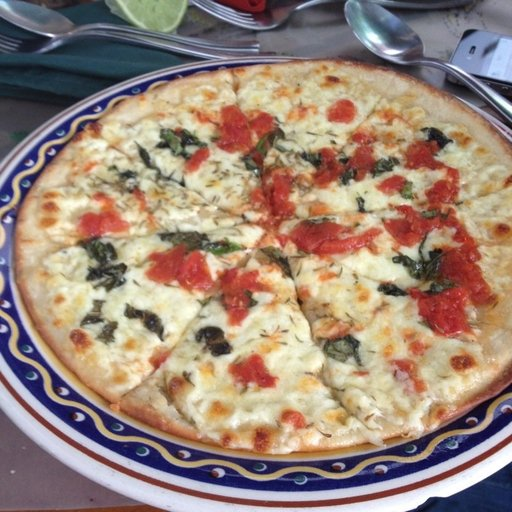

In [60]:
#2.1 visualizing and image
import random
from PIL import Image

#set seed
# random.seed(42)

#1.get all image paths
image_path_list=list(image_path.glob("*/*/*.jpg"))

#2.pick a random image path
random_image_path=random.choice(image_path_list)
print(random_image_path)

#3,get image class from path name
image_class=random_image_path.stem
print(image_class)

#4.open image
img=Image.open(random_image_path)

#5.print metadata 
print(f"random image path :{random_image_path}")
print(f"image class:{image_class}")
print(f"image height :{img.height}")
print(f"image width:{img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

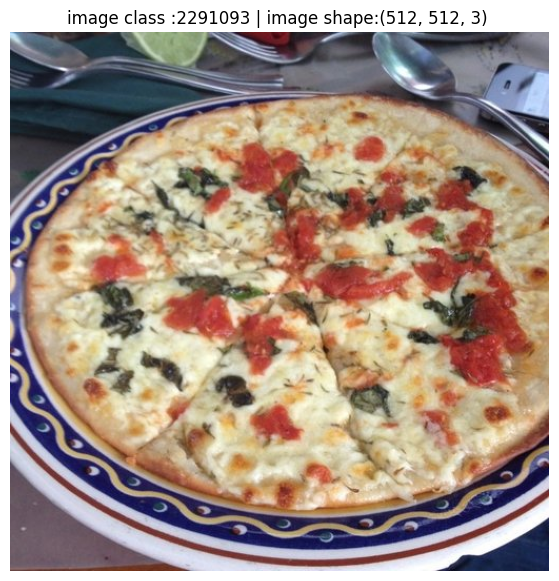

In [61]:
#turn the image into an array
imag_as_array=np.asarray(img)

#plot the image with matplotlib
plt.figure(figsize=(10,7))
plt.imshow(imag_as_array)
plt.title(f"image class :{image_class} | image shape:{imag_as_array.shape} ")
plt.axis(False)


3.turn data into tensors

In [62]:
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [63]:
#3.1 Transforming data with torchvision transforms
data_transform=transforms.Compose([
    #resize our image to 64x64
    transforms.Resize(size=(64,64)),
    #flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),
    #turn the image into torch.tensor
    transforms.ToTensor()
])

In [64]:
data_transform(img).shape

torch.Size([3, 64, 64])

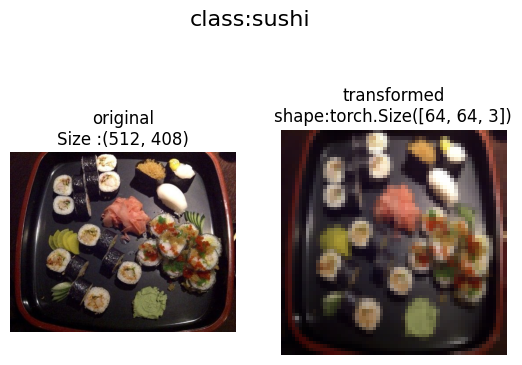

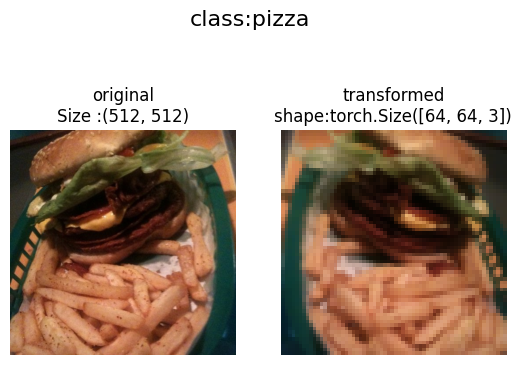

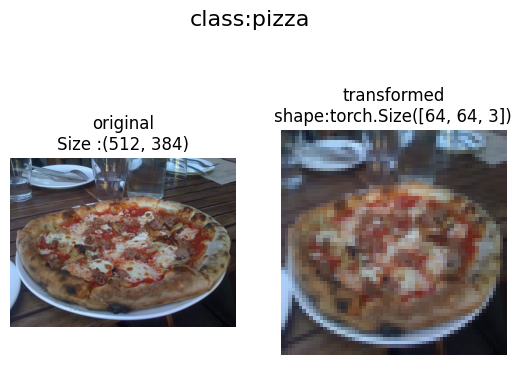

In [65]:
def plot_transformed_image(image_paths:list,transform,n=3,seed=None):
    if seed:
        random.seed(seed)
        
    random_image_paths=random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax=plt.subplots(nrows=1,ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"original\nSize :{f.size}")
            ax[0].axis(False)
            
            #transform and plot target image
            transformed_image=transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"transformed\nshape:{transformed_image.shape}")
            ax[1].axis("off")
            
            fig.suptitle(f"class:{image_path.parent.stem}",fontsize=16)
            
plot_transformed_image(image_paths=image_path_list,
                       transform=data_transform,
                       n=3,
                       seed=42)    

4.loading image data using 'Imagefolder'

In [66]:
#use imagefolder to create dataset(s)
from torchvision import datasets
train_data=datasets.ImageFolder(root=train_dir,
                                transform=data_transform,#transform fot the data
                                target_transform=None)#transform for the label

test_data=datasets.ImageFolder(root=test_dir,
                               transform=data_transform)

train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [67]:
#get class names as list
class_names=train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [68]:
#get class names as dict
class_dict=train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [69]:
#index on the train_data dataset to get a single image and label
img,label=train_data[0][0],train_data[0][1]

originial shape:torch.Size([3, 64, 64]) ->[color_channels,height,width]
image permute :torch.Size([64, 64, 3])->[height,width,colour_channel]


Text(0.5, 1.0, 'pizza')

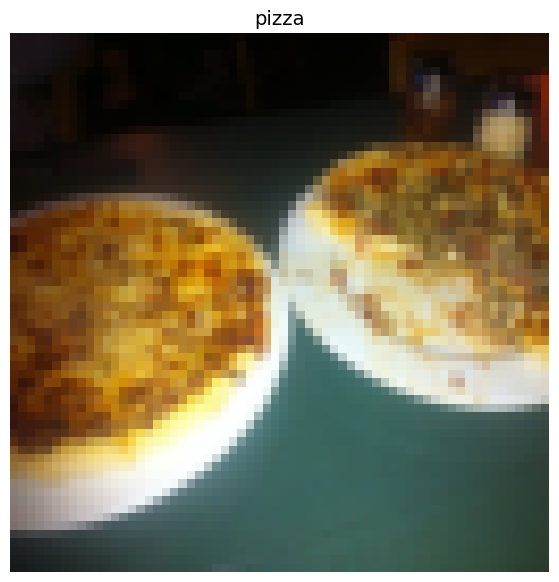

In [70]:
#rearrange the order dimensions
img_premute=img.permute(1,2,0)

#print out on different changes
print(f"originial shape:{img.shape} ->[color_channels,height,width]")
print(f"image permute :{img_premute.shape}->[height,width,colour_channel]")

#plot the range
plt.figure(figsize=(10,7))
plt.imshow(img_premute)
plt.axis("off")
plt.title(class_names[label],fontsize=14)


In [71]:
#4.1 turn loaded image into dataloader
#turn train and test datasets into datasets
from torch.utils.data import DataLoader

BATCH_SIZE=1

train_dataloader=DataLoader(dataset=train_data,
                            batch_size=BATCH_SIZE,
                            num_workers=1,
                            shuffle=True)

test_dataloader=DataLoader(dataset=test_data,
                           batch_size=BATCH_SIZE,
                           num_workers=1,
                           shuffle=False)

In [72]:
len(train_dataloader),len(test_dataloader)

(225, 75)

In [73]:
img,label=next(iter(train_dataloader))

#batch size will be one
print(f"image shape:{img.shape}")
print(f"label shape:{label.shape}")

image shape:torch.Size([1, 3, 64, 64])
label shape:torch.Size([1])


5.option2 loading image data with a custom dataset

In [74]:
import os 
import pathlib 
import torch
from PIL import Image
from torch.utils.data import Dataset
from typing import Tuple,Dict,List

In [75]:
#5.1 creating a helper function to get class names
#setup path directory
target_directory=train_dir
print(target_directory)

#get the class names from the target directory
class_names_found=sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

data\pizza_steak_sushi\train


['pizza', 'steak', 'sushi']

In [76]:
def find_classes(directory:str)->Tuple[list[str],dict[str,int]]:
    #1.get the class names scanning the target directory
    classes=sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    
    #2.raise an error if class names could not be found
    if not classes:
        raise FileNotFoundError(f"could not find any classes in {directory}")
    
    #3.create a directory of index labels 
    class_to_idx={class_name:i for i,class_name in enumerate(classes)}
    return classes,class_to_idx

In [77]:
#5.2 create a custom dataset
#write a custom dataset class
from torch.utils.data import Dataset

#1.subclass torch.utils.data.Dataset
class ImageFOlderCustom(Dataset):
    #2.initialize our custom dataset
    def __init__(self,targ_dir:str,
                 transform=None):
        #create class attributes
        #get all the image paths
        self.path=list(pathlib.Path(targ_dir).glob("*/*.jpg"))
        #steup transforms
        self.transform=transform
        #create classes and class to idx attributes
        self.classes,self.class_to_idx=find_classes(targ_dir)
        
    #create a function to load images
    def load_image(self,index:int)->Image.Image:
        image_path=self.path[index]
        return Image.open(image_path)
    
    #overwrite __len__()
    def __len__(self)->int:
        """return the total number of samples"""
        return len(self.path)  
    
    #6.overwrite __getitem__() method to return a particular sample
    def __getitem__(self, index:int)->Tuple[torch.tensor,int]:
        "returns one sample of data,data and label(X,Y)"
        img=self.load_image(index)
        
        class_name=self.path[index].parent.name #expects path in format data_format/class_name/image.jpg
        class_idx=self.class_to_idx[class_name]
        
        #tansform if neccessary
        if self.transform:
            return self.transform(img),class_idx
        else:
            return img,class_idx#return untransformed image and label

In [78]:
#create a tansform 
train_transform=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transform=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [79]:
#test out image folder custom
train_data_custom=ImageFOlderCustom(targ_dir=train_dir,
                                    transform=train_transform)

test_data_custom=ImageFOlderCustom(targ_dir=test_dir,
                                   transform=test_transform)

In [80]:
train_data_custom,test_data_custom

(<__main__.ImageFOlderCustom at 0x230c5c2ad50>,
 <__main__.ImageFOlderCustom at 0x230c5cc2090>)

In [81]:
len(train_data),len(train_data_custom)

(225, 225)

In [82]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [83]:
#check for equlity
print(train_data_custom.classes==train_data.classes)

True


In [84]:
#5.3 create a function to display random images
#1.take in a dataset and a number of other paramters such as class names and how images to visulize
#2.to prevent the display getting out of hand,let's cap the number of images to see at 10
#3.set the random seed for reproducibility
#4.get a list of random sample indexes from the target dataset.
#5.setup matplotlib.plot 
#6.loop through the random sample images and plot them with matplolib
#7.make sure the dimensions of our images line up with matplotlib

In [85]:
#1.create a function to take in a dataset
def display_random_images(dataset:torch.utils.data.Dataset,
                          classes:list[str]=None,
                          n:int=10,
                          display_shape:bool=True,
                          seed:int=None):
    #2.adjust display if n is to high
    if n>10:
        n=10
        display_shape=False
        print(f"for display,purposes,n shouldn't be larger than 10,setting to 10 and removing shape display")
        
    #3.set the seed
    if seed:
        random.seed(seed)
        
    #4.get random sample indexes
    random_sample_idx=random.sample(range(len(dataset)),k=n)
    
    #5.setup plot 
    plt.figure(figsize=(16,8))
    
    #6.loop through random indexes and plot them with matplolib
    for i,targ_sample in enumerate(random_sample_idx):
        targ_image,targ_label=dataset[targ_sample][0],dataset[targ_sample][1]
        
        #7.adjust tensor dimensions for plotting
        targ_image_adjust=targ_image.permute(1,2,0)#[colour channels,height ,width]
        
        #plot adjusted samples
        plt.subplot(1,n,i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title=f"class:{classes[targ_label]}"
            if display_shape:
                title=title+f"\nshape:{targ_image_adjust.shape}"
        plt.title(title)

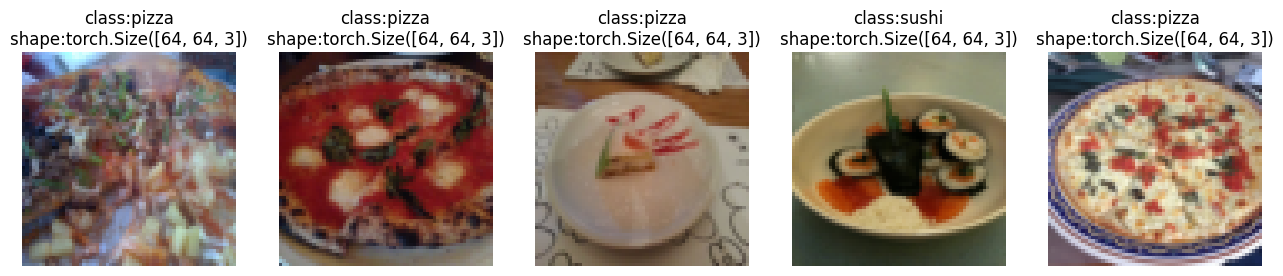

In [86]:
#display random images from image folder create dataset
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=None)

In [89]:
#5.4 turn custom loaded images into dataloader
from torch.utils.data import DataLoader
BATCH_SIZE=1

train_dataloader_custom=DataLoader(dataset=train_data_custom,
                                   batch_size=BATCH_SIZE,
                                   num_workers=0,
                                   shuffle=True)

test_dataloader_custom=DataLoader(dataset=test_data_custom,
                                  batch_size=BATCH_SIZE,
                                  num_workers=os.cpu_count(),
                                  shuffle=False)

train_dataloader_custom,test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x230c5bf83b0>,
 <torch.utils.data.dataloader.DataLoader at 0x230c79b0d10>)

In [90]:
#get image and label from custom dataloader
img_custom,label_custom=next(iter(train_dataloader_custom))

#printout the shape
img_custom.shape,label_custom.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1]))

6.other forms of transform that is data augmentation